In [1]:
library(RaceID)
library(quadprog)
library(pheatmap)

In [13]:
data = readRDS("data_all_sparse.RDS")

dim(data)

sc <- SCseq(data)

sc <- filterdata(sc,mintotal=2000,CGenes=grep("^(mt|Gm\\d|Rp(l|s))",rownames(D),value=TRUE))

expData  <- getExpData(sc)

dim(expData)

[1] 20035 48305

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.9 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.9 GiB”


[1]  5263 48175

In [2]:
res <- readRDS('obj_savegm_rp_filt_all3.RDS')

In [11]:
length(res)

[1] 10

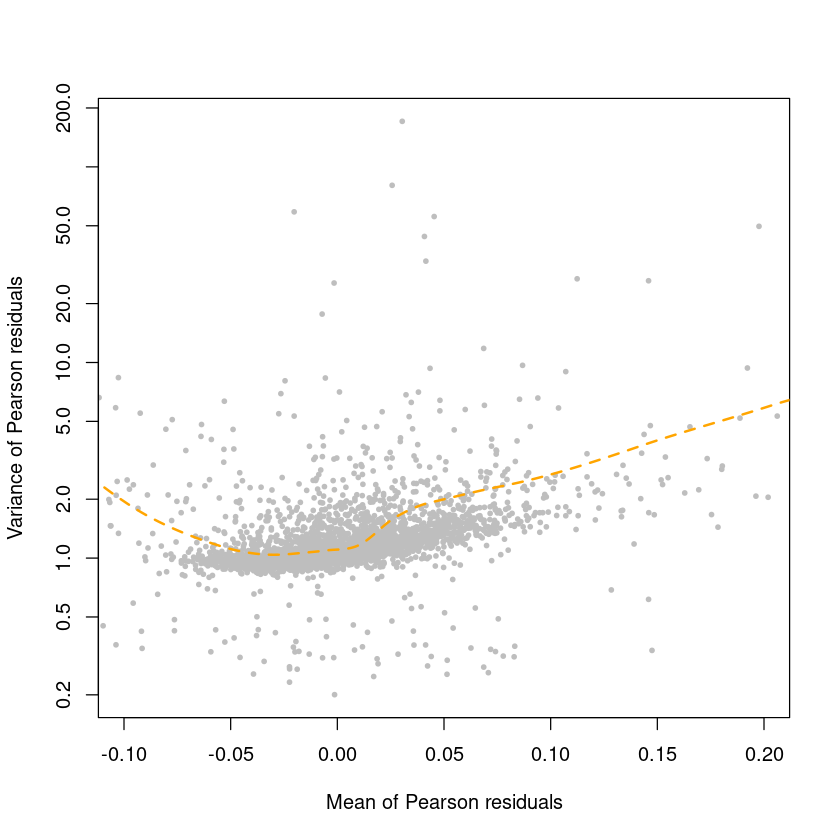

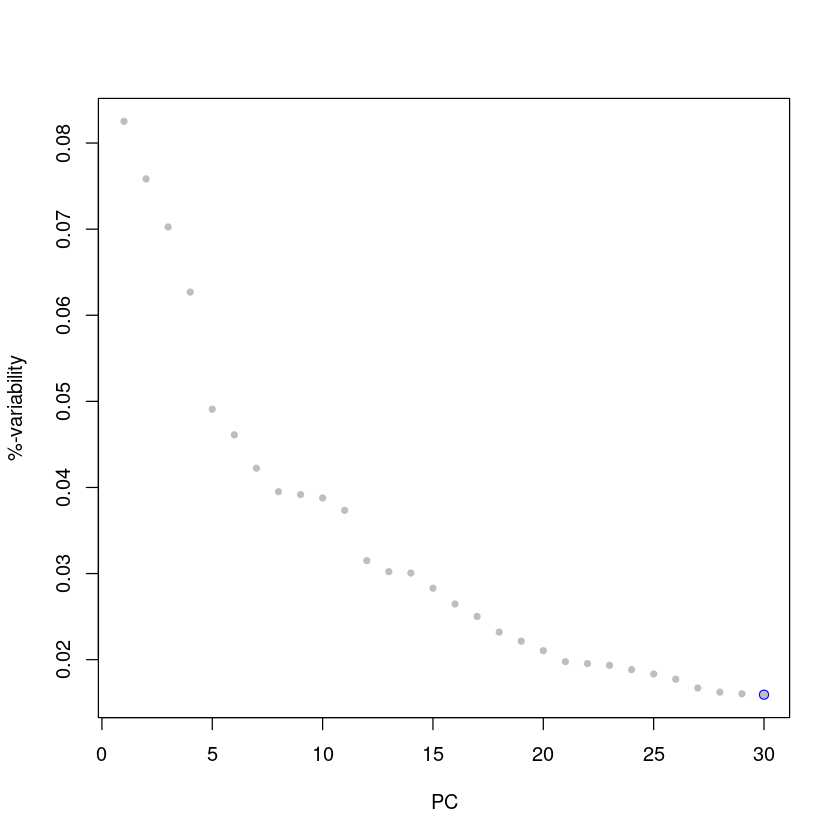

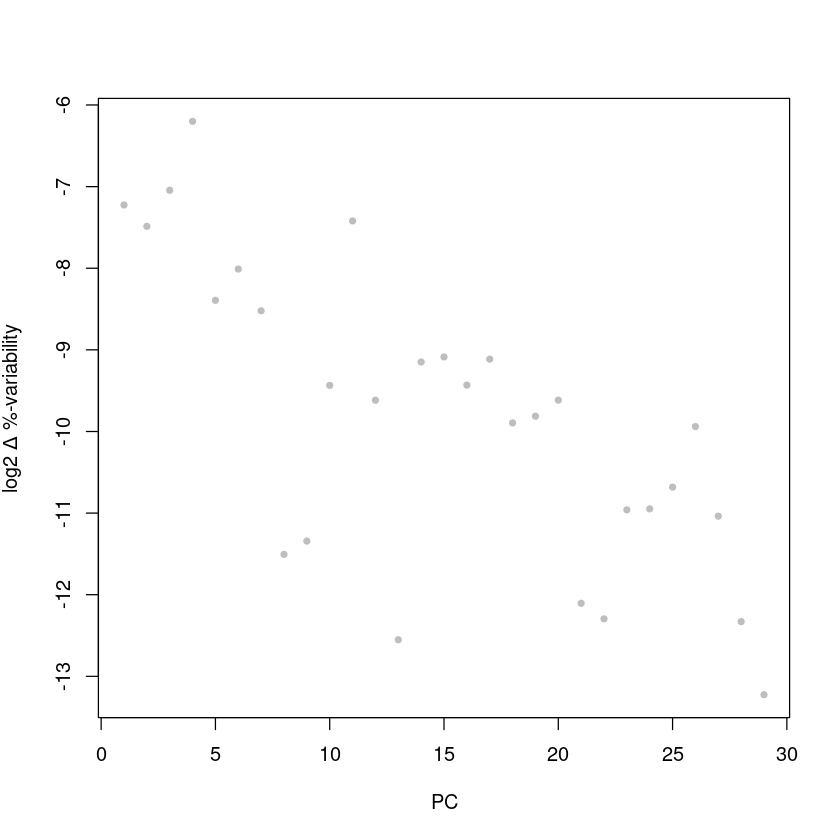

In [4]:
plotPearsonRes(res,log=TRUE,xlim=c(-.1,.2))

plotPC(res)

plotPC(res,logDiff=TRUE)

In [9]:
cl <- graphCluster(res,pvalue=0.01)

In [6]:
probs <- transitionProbs(res,cl)

In [14]:
# time consuming
sc <- updateSC(sc,res=res,cl=cl)
sc <- comptsne(sc,perplexity=200)
sc <- compumap(sc,min_dist=1.5,spread=2)

In [15]:
saveRDS(sc,'sc_temp_obj.RDS')


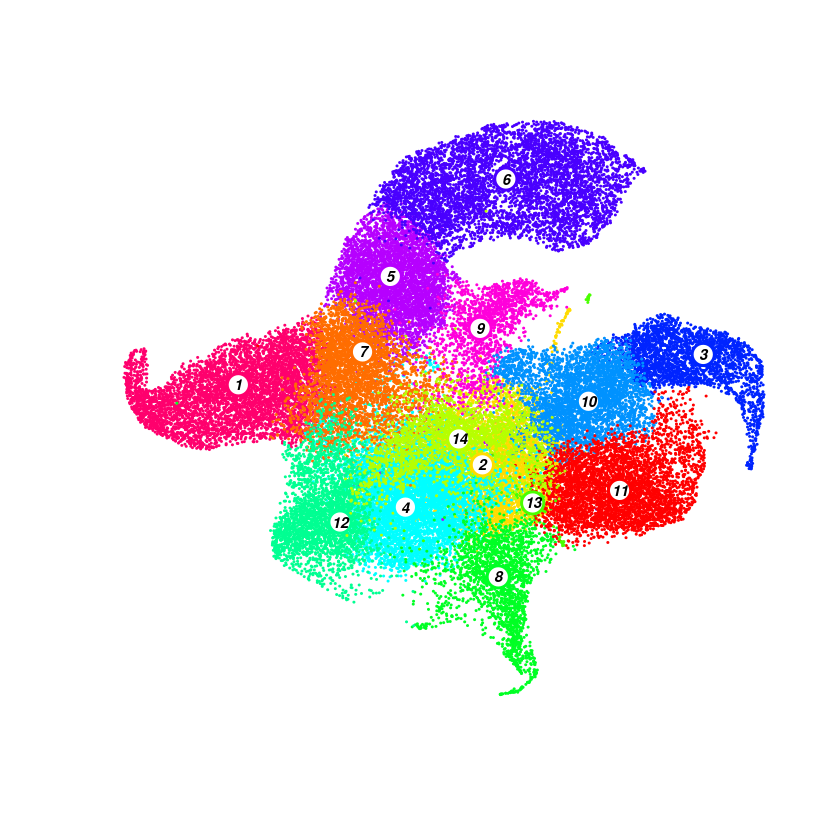

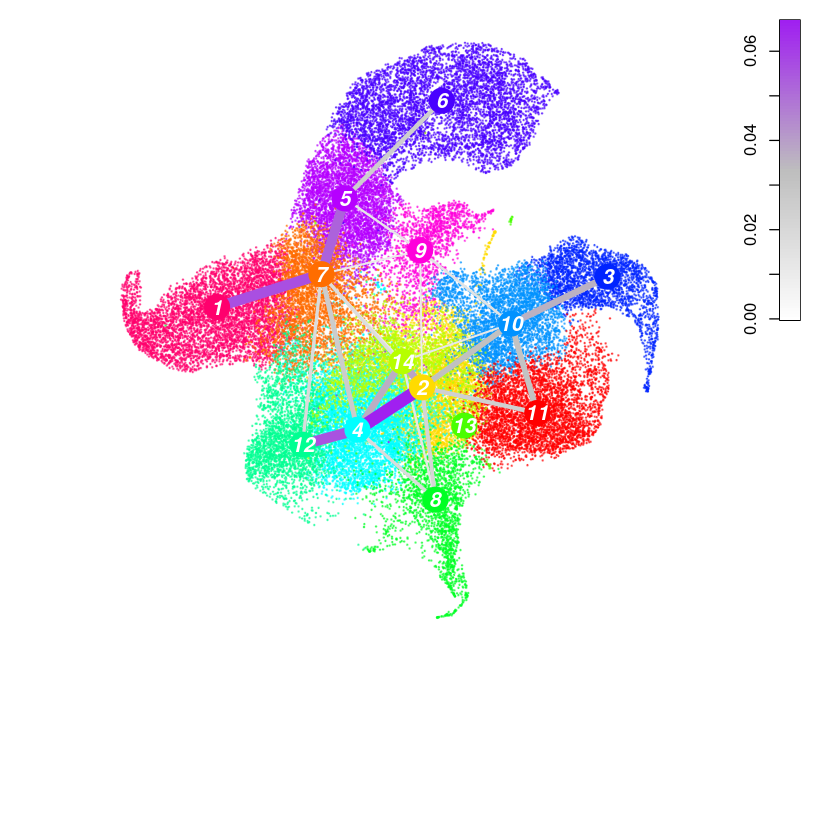

In [16]:
plotmap(sc, um=TRUE, cex=0.3)
plotTrProbs(sc,probs,tp=.5,prthr=0.01,cthr=0,um=TRUE, cex=0.3)

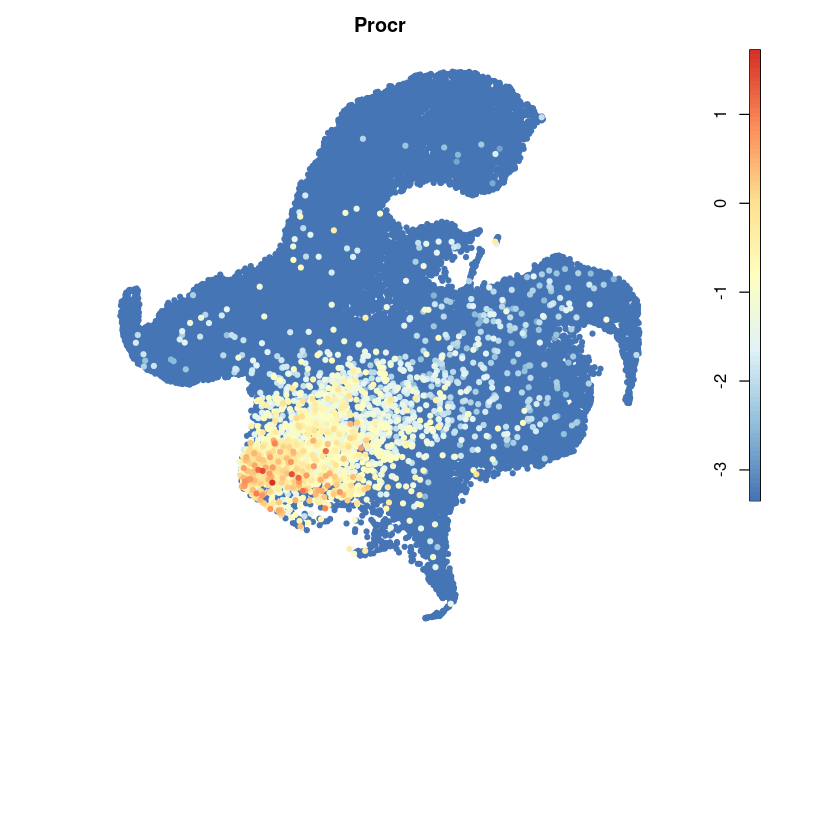

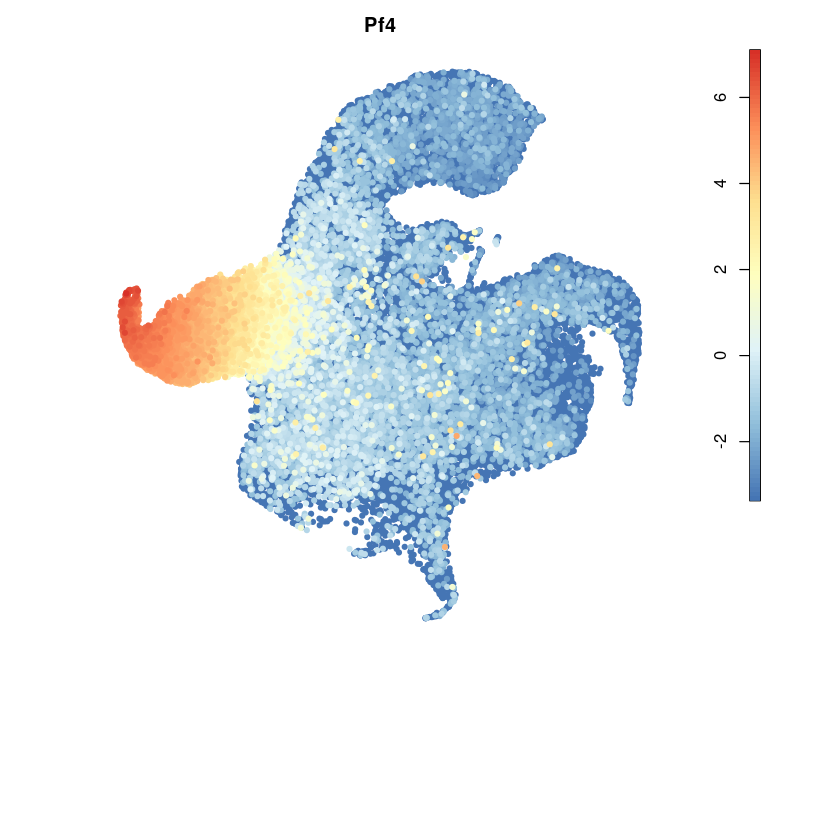

In [17]:
plotexpmap(sc,"Procr",logsc=TRUE,um=TRUE,cex=1)
# plotexpmap(sc,"Klf1",logsc=TRUE,um=TRUE,cex=1)
plotexpmap(sc,"Pf4",logsc=TRUE,um=TRUE,cex=1)

In [3]:
sc <- readRDS('sc_temp_obj.RDS')

In [4]:
x <- getFilteredCounts(sc,minexpr=5,minnumber=5)

In [ ]:
'a'

In [5]:
noise <- compTBNoise(res,x,pvalue=0.01,gamma = 1.2,no_cores=5) # this takes 28 nodes and max2h to run

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.9 GiB”


In [ ]:
write.csv(noise$epsilon,'./noise_def.csv')

In [6]:
saveRDS(sc,'noise_def_obj.RDS')


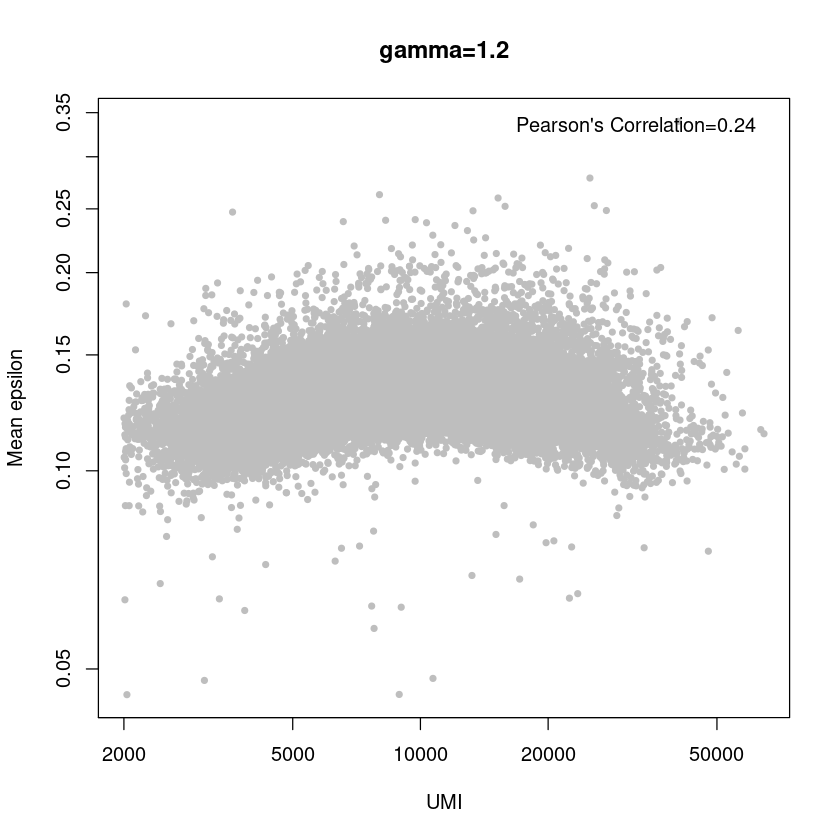

In [7]:
plotUMINoise(sc,noise,log.scale=TRUE)

In [10]:
sc <- updateSC(sc,res=res,cl=cl,noise=noise)

In [11]:
saveRDS(sc,'noise_def_sc_obj.RDS')

In [23]:
'c'

[1] "c"

In [12]:
ngenes <- diffNoisyGenesTB(noise,cl,set=1,no_cores=1) #also time consuming
head(ngenes)

,mu.set,mu.bgr,mu.all,eps.set,eps.bgr,eps.all,log2FC,pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ppbp,0.2032201,0.002081909,0.02425663,0.5333458,0.002044686,0.06433925,2.633792,0
Mrvi1,0.2487870,0.005894620,0.03267258,0.5244059,0.006908290,0.06715689,2.546110,0
Clec1b,0.3011895,0.003650127,0.03645271,0.4926075,0.003971181,0.06103217,2.510893,0
Timp3,0.8733439,0.019907749,0.11399584,0.9861368,0.122210928,0.22294537,2.289204,0
Hs3st1,0.1641594,0.006832080,0.02417682,0.3905215,0.013652742,0.05794641,2.109684,0
Gm10419,0.5011292,0.014841002,0.06845243,0.3581439,0.015990099,0.05591410,1.981799,0


In [13]:
write.csv(ngenes,'./diff_noisy_genes_def.csv')

In [14]:
'b'

[1] "b"

In [15]:
2+1

[1] 3

# More about the noise

In [16]:
qn <- quantKnn(res, noise, sc, pvalue = 0.01, minN = 5, no_cores = 5)

In [17]:
write.csv(qn$noise.av,'./noiseav_def.csv')

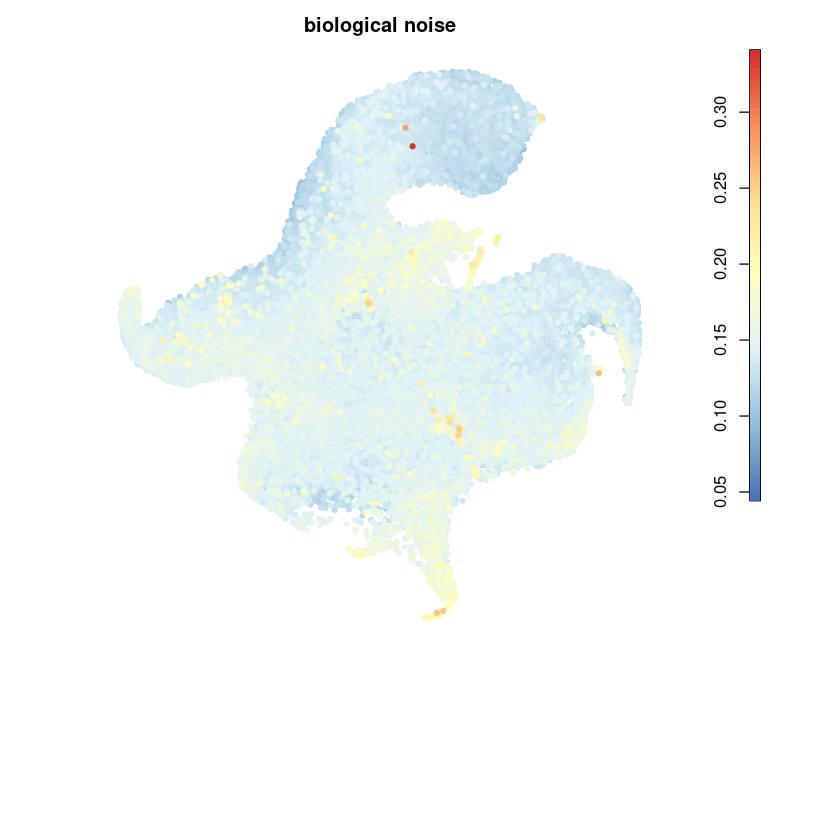

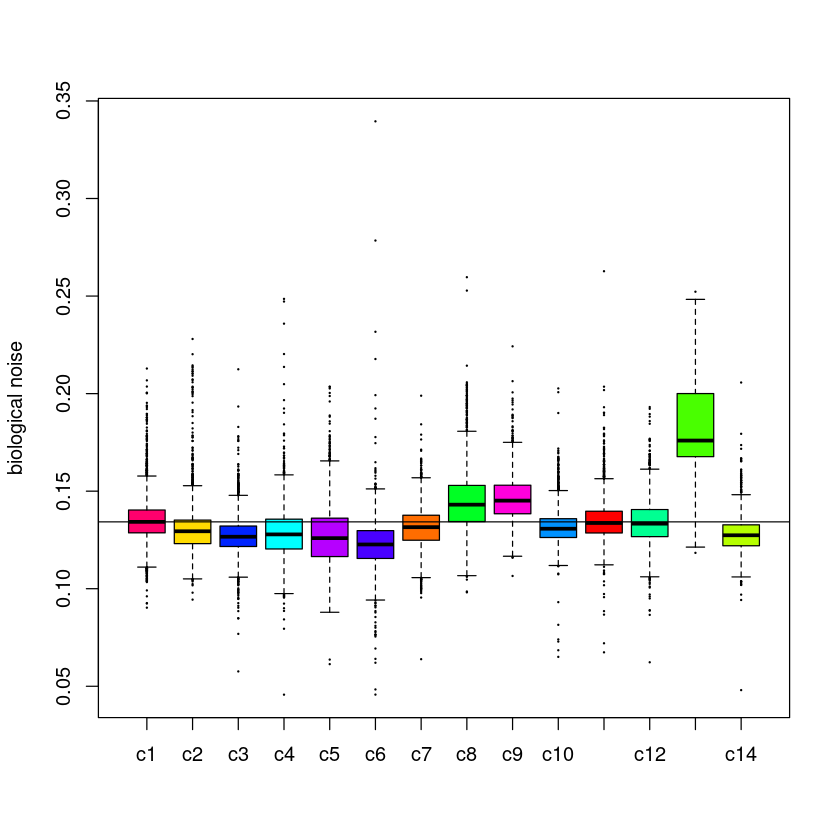

In [18]:
#Noise levels across cell clusters
StemCluster <- 1
plotQuantMap(qn,"noise.av",sc,um=TRUE,ceil=.6,cex=1)
plotQuantMap(qn,"noise.av",sc,box=TRUE,cluster=StemCluster)

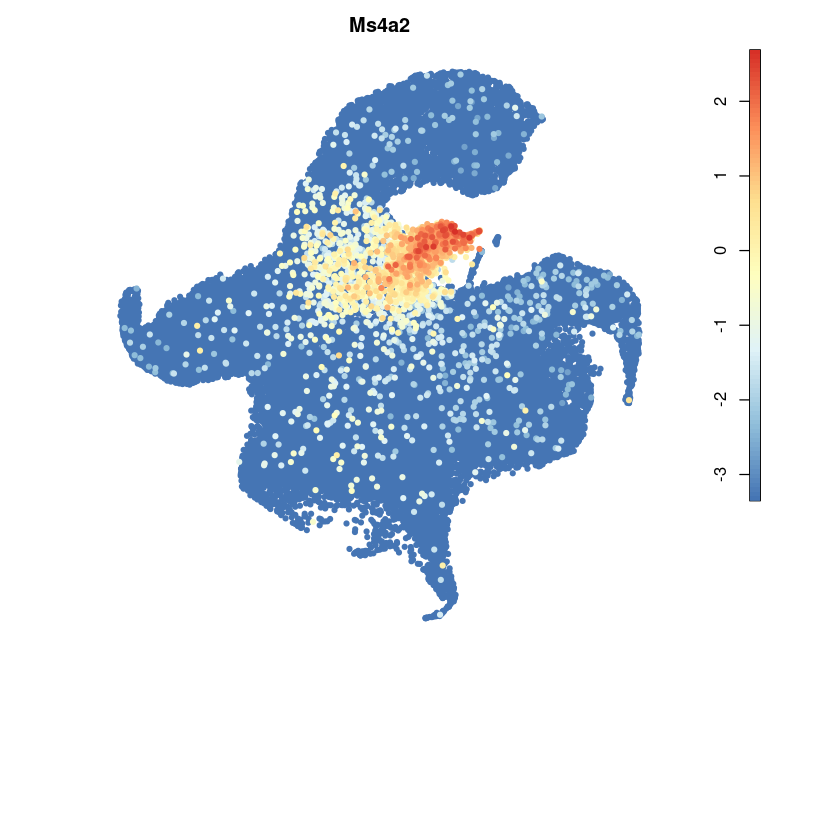

In [19]:
plotexpmap(sc,"Ms4a2",logsc=TRUE,um=TRUE,cex=1)


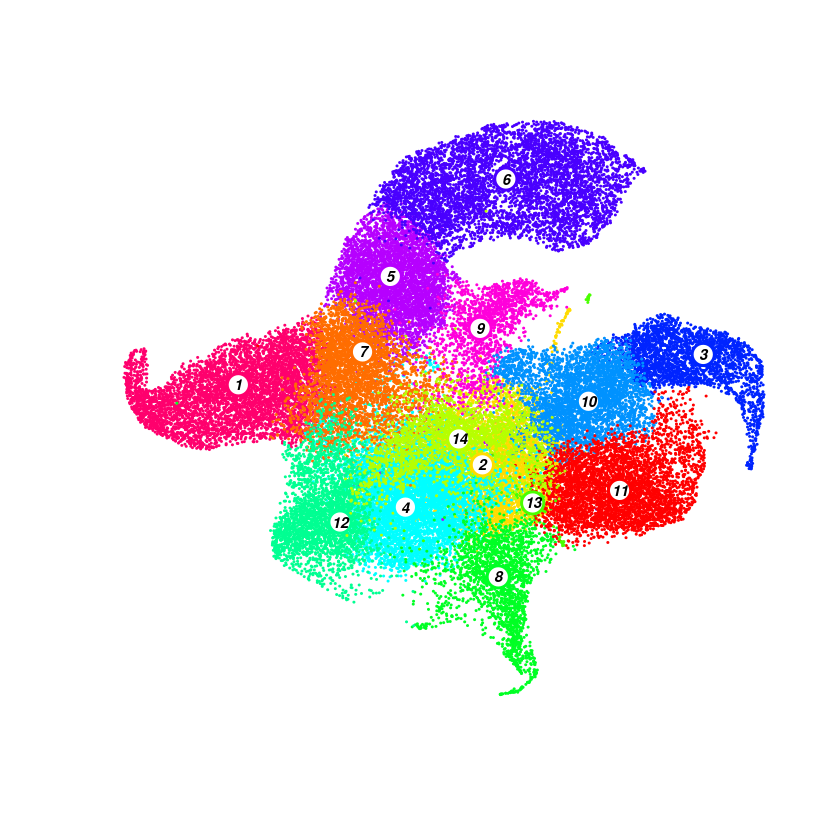

In [20]:
plotmap(sc, um=TRUE, cex=0.3)

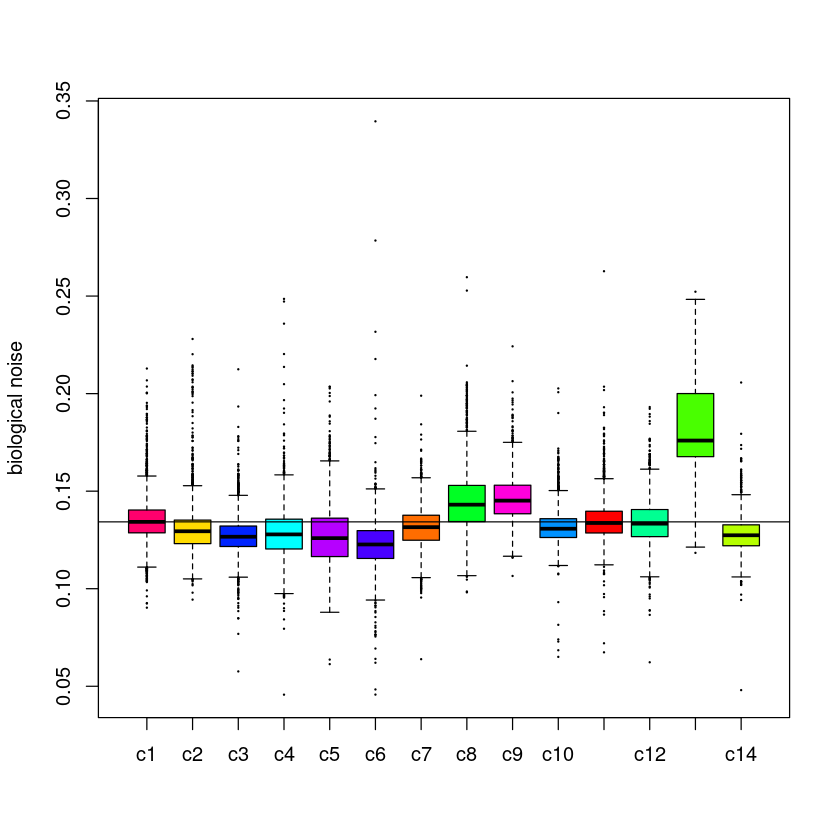

In [21]:
plotQuantMap(qn,"noise.av",sc,box=TRUE,cluster=StemCluster)

In [28]:
length(qn$noise.av)

[1] 48175

In [30]:
length(cl)

[1] 3

In [36]:
write.csv(cl$partition,"cl_partition.csv")